<a href="https://colab.research.google.com/github/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/Word_Embedding_spaCy_Gensim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Word Embedding**





O TF-IDF (Term Frequency-Inverse Document Frequency), como vimos no notebook anterior, melhorou a representação de documentos ao ponderar a importância das palavras em um documento dentro de um corpus. No entanto, o TF-IDF ainda trata as palavras como unidades independentes, sem considerar o contexto em que aparecem ou suas relações semânticas intrínsecas. Embora útil e bastante simples, essa técnica falha em capturar qualquer relação semântica entre as palavras; "rei" e "rainha" são tão distantes quanto "rei" e "banana". Além disso, o vocabulário cresce rapidamente, levando a vetores de alta dimensionalidade e esparsos.

# Word Embeddings: Incorporações de Palavras, Vetores que Capturam Significado

Word Embeddings (ou incorporações de palavras) representam um salto qualitativo na forma como as palavras são representadas numericamente. A premissa fundamental por trás dos word embeddings é a hipótese distribucional, que afirma que palavras que aparecem em contextos semelhantes tendem a ter significados semelhantes. Em outras palavras, "você conhece uma palavra pela companhia que ela mantém".

Em vez de vetores esparsos e de alta dimensão, os word embeddings são vetores densos e de baixa dimensão (tipicamente entre 50 e 300 dimensões). Cada dimensão do vetor pode ser interpretada como uma "característica latente" da palavra, capturando aspectos semânticos (ex: gênero, realeza, tipo de alimento) e sintáticos (ex: substantivo, verbo) de seu significado.

 <br>

<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/fig2ans.png?raw=true?raw=true" width=500>


<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/fig3.png?raw=true?raw=true" width=500>

<small>
https://www.cs.cmu.edu/~dst/WordEmbeddingDemo/tutorial.html

# Propriedades Chave dos Word Embeddings

* **Similaridade Semântica**: Palavras com significados semelhantes (ex: "rei" e "rainha", "gato" e "felino") possuem vetores que estão próximos no espaço vetorial. A similaridade pode ser medida por métricas como a similaridade de cosseno.

* **Relações Analógicas**: Os embeddings podem capturar relações complexas. Por exemplo, a relação vetorial entre "rei" e "rainha" é similar à relação entre "homem" e "mulher". Matematicamente, vetor("rei") - vetor("homem") + vetor("mulher") resulta em um vetor muito próximo ao vetor("rainha").




## **Analogias por meio da aritmética vetorial**

<br>

<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/fig3b.png?raw=true?raw=true" width=300>

<br>
<br>
<br>

<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/fig4.png?raw=true?raw=true" width=500>

## Mas pode não ser exatamente assim... rs

<br>

<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/tab_embedding_rainha.png?raw=true?raw=true" width=500>

Nissim et al. (2019): https://arxiv.org/abs/1905.09866

# Medindo a similaridade com o produto escalar

Dados dois vetores $[x₁ , y₁ ]$ e $[x₂ , y₂ ]$ , a distância euclidiana entre eles é $\sqrt{(x₁ - x₂ ) ² + ( y₁ - y₂ ) ²}$. O produto escalar é mais simples: é $x₁ · x₂ + y₁ · y₂ $. O produto escalar é proporcional ao cosseno do ângulo entre os dois vetores. Mas, para que essa seja uma medida de similaridade adequada, precisamos fazer um pequeno ajuste nos vetores.

Lembrando:

$$sim(a,b) = cos(a,b) = \frac{a.b}{|a||b|}$$


<br>


<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/figA.png?raw=true?raw=true" width=350>
<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/figB.png?raw=true?raw=true" width=350>
<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/figC.png?raw=true?raw=true" width=350>

<br>
<br>

<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/figD.png?raw=true?raw=true" width=500>

# Arquiteturas Populares de Word Embedding

O **Word Embedding** é uma técnica de redução de dimensionalidade e, em princípio, técnicas como o `PCA` e SVD (Singular Vector Decompositions) podem ser aplicadas para se conseguir um vetor de presentação reduzido (veja o material de PCA na página do curso). Mas outros modelos apresentam uma eficiência maior quando do emprego em NLP e se tornaram o padrão desse técnica. Dentre eles encontramos o modelo seminal do `Word2Vec` da Google (2013), o `Gensim`,  `FastText` (Meta) e o `GloVe` (Stanford).

> Além dos materiais de PCA, visite https://projector.tensorflow.org/.





# Word2Vec (Google)

<br>
<br>

<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/mikolov.png?raw=true?raw=true" width=400>

<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/mikolov2.png?raw=true?raw=true" width=400>


Acesse: https://scholar.google.com/scholar?hl=pt-BR&as_sdt=0%2C5&q=word2vec+tomas+mikolov&oq=word2vec

<br>
<br>
<br>

Desenvolvido por Tomas Mikolov e sua equipe na Google, o Word2Vec é um dos modelos mais influentes. Ele utiliza uma rede neural simples para aprender os embeddings. Possui duas arquiteturas principais:

> - **CBOW (Continuous Bag-of-Words)**: Prevê a palavra alvo a partir de seu contexto (as palavras ao redor). É mais rápido e bom para palavras frequentes.

> - **Skip-gram**: Prevê as palavras de contexto a partir da palavra alvo. É mais lento, mas funciona melhor para palavras raras e corpora maiores.

<br>

<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/cbow1.png?raw=true?raw=true" width=400>

<br>

<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/cbow_skip-gram1.png?raw=true?raw=true" width=400>

<br>

<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/cbow2.png?raw=true?raw=true" width=250>

<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/skip-gram2.png?raw=true?raw=true" width=250>

<br>
<br>

<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/cbow_skip-gram.png?raw=true?raw=true" width=400>


<br>
<br>

Rong, X. (2014). **word2vec parameter learning explained**. arXiv preprint arXiv:1411.2738.


In [2]:
from IPython.display import IFrame

IFrame(src="https://ronxin.github.io/wevi/", width="100%", height="600px")

# Interpretando o Word Embedding

<br>

<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/coocorrencias1.png?raw=true?raw=true" width=350>

<br>
<br>

<img src="https://github.com/Rogerio-mack/Modelos_de_Linguagem_e_Generativos/blob/main/figures/coocorrencias.png?raw=true?raw=true" width=350>



# Outros modelos

**GloVe (Stanford)**. O GloVe (Global Vectors for Word Representation) combina as vantagens de duas abordagens: a contagem de coocorrência global (como na Análise Semântica Latente) e a previsão baseada em contexto local (como no Word2Vec). Ele constrói uma matriz de coocorrência de palavras e depois a fatoriza para obter os vetores de palavras.

**FastText (Facebook)**. Uma extensão do Word2Vec, o FastText trata cada palavra como um conjunto de n-gramas de caracteres. Por exemplo, a palavra "banana" com n=3 seria representada por <ba, ban, ana, nan, na>, an>. Isso permite que o FastText gere vetores para palavras fora do vocabulário (OOV - Out-Of-Vocabulary) e geralmente funciona melhor para idiomas com morfologia rica.

# Exemplos de Implementação `Gensim` e `spaCy`

Neste exemplo, vamos explorar as duas abordagens:
1.  **spaCy:** Utilizar um modelo pré-treinado para obter vetores e calcular similaridade.
2.  **Gensim:** Treinar um modelo Word2Vec simples do zero com um pequeno corpus.


### Instalando as bibliotecas e modelos necessários


In [3]:
!pip install spacy gensim nltk pandas
# Baixa um modelo médio do spaCy para português com vetores de palavras
!python -m spacy download pt_core_news_md

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 18.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### Exemplo 1: Usando Embeddings Pré-treinados com spaCy

O `spaCy` torna trivial o acesso a vetores de palavras. Vamos carregar um modelo pré-treinado para português e explorar as relações semânticas.

In [4]:
import spacy

# Carrega o modelo de linguagem do spaCy com vetores de palavras
nlp = spacy.load("pt_core_news_md")

# Processa algumas palavras
rei = nlp("rei")
rainha = nlp("rainha")
homem = nlp("homem")
mulher = nlp("mulher")
carro = nlp("carro")

# Verifica se as palavras têm vetores associados
print(f"A palavra 'rei' tem vetor? {rei.has_vector}")
print(f"Dimensão do vetor: {rei.vector.shape[0]}")

# Calcula a similaridade de cosseno entre palavras
print(f"Similaridade entre 'rei' e 'rainha': {rei.similarity(rainha):.3f}")
print(f"Similaridade entre 'homem' e 'mulher': {homem.similarity(mulher):.3f}")
print(f"Similaridade entre 'rei' e 'carro': {rei.similarity(carro):.3f}")

# Testando a analogia: rei - homem + mulher ≈ rainha
vetor_analogia = rei.vector - homem.vector + mulher.vector

# Encontrando a palavra mais próxima do vetor resultante
from scipy.spatial.distance import cosine

palavras_proximas = []
for vocab_word in nlp.vocab:
    if vocab_word.has_vector and vocab_word.is_lower and vocab_word.is_alpha:
        dist = cosine(vetor_analogia, vocab_word.vector)
        palavras_proximas.append((vocab_word.text, dist))

palavras_proximas.sort(key=lambda item: item[1])
print(f"Resultado da analogia 'rei - homem + mulher': {palavras_proximas[:5]}")

A palavra 'rei' tem vetor? True
Dimensão do vetor: 300
Similaridade entre 'rei' e 'rainha': 0.600
Similaridade entre 'homem' e 'mulher': 0.660
Similaridade entre 'rei' e 'carro': 0.091
Resultado da analogia 'rei - homem + mulher': [('rei', np.float32(0.108278275)), ('rainha', np.float32(0.26134592)), ('sra', np.float32(0.62611556)), ('mulher', np.float32(0.63562727)), ('homem', np.float32(0.8249161))]


In [5]:
cosine(rei.vector, rei.vector)

np.float32(0.0)

In [6]:
import numpy as np

first = True
for v in [rei.vector, rainha.vector, homem.vector, mulher.vector, carro.vector, vetor_analogia]:
  if first:
    vectors_ = v
    first = False
  else:
    vectors_ = np.vstack((vectors_,v))

print(vectors_.shape)

(6, 300)


In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
vectors_ = scaler.fit_transform(vectors_)

# Perform PCA with 3 components
pca = PCA(n_components=3)
vectors_pca = pca.fit_transform(vectors_)

print("PCA results:")
print(vectors_pca)

PCA results:
[[-16.267511    1.5549502   9.3229065]
 [  1.8532573  -1.7501664  -9.236989 ]
 [  9.272426   -8.998854    9.840587 ]
 [  8.386019   -8.525687   -5.453439 ]
 [ 13.909733   15.691643    1.4980496]
 [-17.153923    2.028112   -5.9711156]]


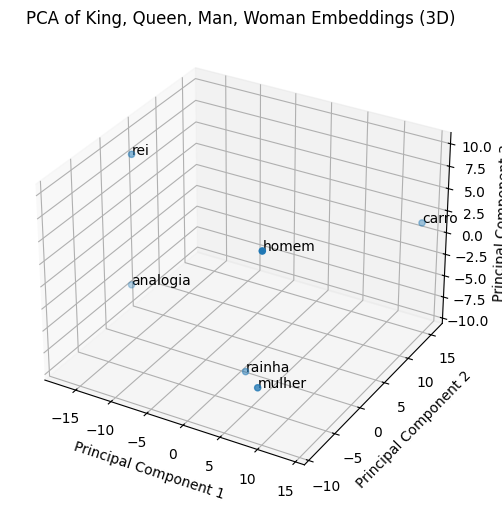

In [8]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

names = ['rei','rainha','homem','mulher','carro','analogia']

ax.scatter(vectors_pca[:, 0], vectors_pca[:, 1], vectors_pca[:, 2])

for i, name in enumerate(names):
    ax.text(vectors_pca[i, 0], vectors_pca[i, 1], vectors_pca[i, 2], name, size=10, zorder=1, color='k')

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('PCA of King, Queen, Man, Woman Embeddings (3D)')

plt.show()

PCA results (2D):
[[-16.267511    1.5549502]
 [  1.8532573  -1.7501664]
 [  9.272426   -8.998854 ]
 [  8.386019   -8.525687 ]
 [ 13.909733   15.691643 ]
 [-17.153923    2.028112 ]]


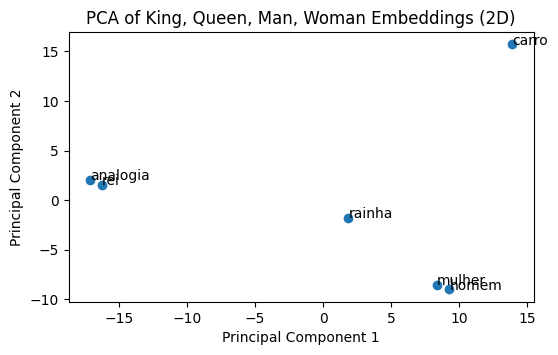

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Perform PCA with 2 components
pca_2d = PCA(n_components=2)
vectors_pca_2d = pca_2d.fit_transform(vectors_)

print("PCA results (2D):")
print(vectors_pca_2d)

fig = plt.figure(figsize=(6,3.5))
ax = fig.add_subplot(111)

names = ['rei','rainha','homem','mulher','carro','analogia']

ax.scatter(vectors_pca_2d[:, 0], vectors_pca_2d[:, 1])

for i, name in enumerate(names):
    ax.text(vectors_pca_2d[i, 0], vectors_pca_2d[i, 1], name, size=10, zorder=1, color='k')

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('PCA of King, Queen, Man, Woman Embeddings (2D)')

plt.show()

In [10]:
cosine(rainha.vector, vetor_analogia)

np.float32(0.26134592)

### Exemplo 2: Treinando seu Próprio Modelo Word2Vec com Gensim

Quando você tem um *corpus* de documentos específico, como textos médicos, jurídicos, etc. ou precisa de mais controle sobre o seu modelo, você pode treinar seu próprio modelo. O Gensim, neste caso, é uma das alternativas.

In [13]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [14]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk

# Baixa o tokenizador do NLTK se ainda não tiver
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")

# Corpus de exemplo para treinar o Word2Vec
sentences = [
    "O rei governa o reino com sabedoria",
    "A rainha comanda o exército com bravura",
    "O homem e a mulher passeiam no parque",
    "O príncipe herdeiro é filho do rei e da rainha",
    "O sol brilha no céu azul durante o dia",
    "A lua ilumina a noite escura"
]

# Tokeniza as sentenças (Gensim espera uma lista de listas de tokens)
tokenized_sentences = [word_tokenize(s.lower()) for s in sentences]

# Treina o modelo Word2Vec
# vector_size: dimensão dos vetores de palavras (baixa para este exemplo)
# window: tamanho da janela de contexto (quantas palavras antes e depois considerar)
# min_count: ignora palavras com frequência total menor que este valor
# workers: número de threads para treinamento (paralelização)
model = Word2Vec(sentences=tokenized_sentences, vector_size=2, window=5, min_count=1, workers=4)

# Salva o modelo treinado (opcional)
model.save("word2vec_custom.model")

# Obtém o vetor para uma palavra
print(f"Vetor para 'rei': {model.wv['rei'][:5]}...")

# Encontra as palavras mais similares no nosso pequeno corpus
print("Palavras mais similares a 'rei':")
print(model.wv.most_similar('rei'))

print("Palavras mais similares a 'rainha':")
print(model.wv.most_similar('rainha'))

# Calcula a similaridade entre duas palavras
print(f"Similaridade entre 'rei' e 'rainha': {model.wv.similarity('rei', 'rainha'):.3f}")
print(f"Similaridade entre 'rei' e 'sol': {model.wv.similarity('rei', 'sol'):.3f}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


Vetor para 'rei': [-0.22683066  0.32770258]...
Palavras mais similares a 'rei':
[('governa', 0.9983587861061096), ('parque', 0.9977335929870605), ('comanda', 0.9701507091522217), ('azul', 0.9038584232330322), ('mulher', 0.8955938220024109), ('é', 0.8848082423210144), ('o', 0.8615705966949463), ('sabedoria', 0.7228444218635559), ('homem', 0.7190725803375244), ('brilha', 0.4642408788204193)]
Palavras mais similares a 'rainha':
[('no', 0.9999542236328125), ('da', 0.9987890720367432), ('céu', 0.9869688749313354), ('herdeiro', 0.984003484249115), ('ilumina', 0.9786288738250732), ('escura', 0.9592344164848328), ('reino', 0.9078197479248047), ('brilha', 0.8672985434532166), ('príncipe', 0.689740777015686), ('homem', 0.6669144034385681)]
Similaridade entre 'rei' e 'rainha': -0.038
Similaridade entre 'rei' e 'sol': -0.952


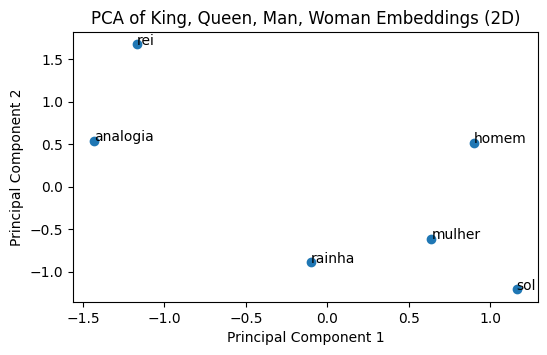

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(6,3.5))
ax = fig.add_subplot(111)

names = ['rei','rainha','homem','mulher','sol','analogia']

ax.scatter(vectors_[:, 0], vectors_[:, 1])

for i, name in enumerate(names):
    ax.text(vectors_[i, 0], vectors_[i, 1], name, size=10, zorder=1, color='k')

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title('PCA of King, Queen, Man, Woman Embeddings (2D)')

plt.show()

# Como ficam os documentos???

A grande maioria dos algoritmos de Machine Learning clássicos e muitas arquiteturas de Redes Neurais requerem uma entrada de tamanho fixo. Mas o Word2Vec e outras técnicas de embedding fornecem um vetor fixo por palavra... **Como fica uma sentença ou um documento? Seriam vetores de tamanho variável...**.


